In [78]:
import soccerdata as sd

fbref = sd.FBref(
    leagues="Big 5 European Leagues Combined",
    seasons="2025-2026"
)

df = fbref.read_player_season_stats(stat_type="standard")
df = df.reset_index()

[05/04/26 20:32:12] INFO     Saving cached data to /Users/adirosenstock/soccerdata/data/FBref        ]8;id=15691387;file:///opt/anaconda3/lib/python3.11/site-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=15691388;file:///opt/anaconda3/lib/python3.11/site-packages/soccerdata/_common.py#250\250]8;;\

[05/04/26 20:32:16] WARNING  /opt/anaconda3/lib/python3.11/site-packages/soccerdata/fbref.py:171:   ]8;id=15691393;file:///opt/anaconda3/lib/python3.11/warnings.py\warnings.py]8;;\:]8;id=15691394;file:///opt/anaconda3/lib/python3.11/warnings.py#110\110]8;;\
                             FutureWarning: The behavior of DataFrame concatenation with empty or                  
                             all-NA entries is deprecated. In a future version, this will no longer                
                             exclude empty or all-NA columns when determining the result dtypes. To                
                             retain the old behavior, exclude the relevant entries before the                      
                             concat operation.                                                                     
                               pd.concat(dfs)                                                                      
                                                                                                                   

In [79]:
df.columns = [
    col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
    for col in df.columns
]

df

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK
0,ENG-Premier League,2526,Arsenal,Ben White,ENG,DF,28-208,1997,11,8,...,0,0,0,0,0,0.0,0.13,0.13,0.0,0.13
1,ENG-Premier League,2526,Arsenal,Bukayo Saka,ENG,"FW,MF",24-241,2001,29,23,...,6,1,1,1,0,0.31,0.18,0.48,0.26,0.44
2,ENG-Premier League,2526,Arsenal,Christian Nørgaard,DEN,MF,32-055,1994,6,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
3,ENG-Premier League,2526,Arsenal,Cristhian Mosquera,ESP,DF,21-311,2004,17,7,...,0,0,0,3,0,0.0,0.0,0.0,0.0,0.0
4,ENG-Premier League,2526,Arsenal,David Raya,ESP,GK,30-231,1995,35,35,...,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2769,NaN,2526,Wolfsburg,Pharell Hensel,GER,MF,19-056,2007,5,1,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
2770,NaN,2526,Wolfsburg,Sael Kumbedi,FRA,"DF,MF",21-039,2005,22,18,...,0,0,0,2,0,0.0,0.28,0.28,0.0,0.28
2771,NaN,2526,Wolfsburg,Vinicius Souza,BRA,MF,26-321,1999,22,20,...,0,0,0,4,0,0.0,0.0,0.0,0.0,0.0
2772,NaN,2526,Wolfsburg,Václav Černý,CZE,"FW,MF",28-199,1997,2,0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0


In [80]:
df["Playing Time_Min"] = pd.to_numeric(df["Playing Time_Min"], errors="coerce")
df["Performance_Gls"] = pd.to_numeric(df["Performance_Gls"], errors="coerce")
df["age"] = df["age"].astype(str).str.split("-").str[0]
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [81]:
high_g_a_per_90_minutes = df[
    (df["age"] <= 23) &
    (df["Playing Time_Min"] >= 600) &
    (df["Per 90 Minutes_G+A"] >= 0.5)
]

cols = [
    "player",
    "team",
    "league",
    "nation",
    "pos",
    "age",
    "Playing Time_Min",
    "Performance_Gls",
    "Performance_Ast",
    "Performance_G+A",
    "Per 90 Minutes_G+A"
]

high_g_a_per_90_minutes = high_g_a_per_90_minutes[cols].copy()

In [ ]:
players_to_remove = [
    "Cole Palmer",
    "Lamine Yamal",
    "Hugo Ekitike",
    "Benjamin Šeško",
    "Arda Güler",
    "Lennart Karl",
    "Désiré Doué",
    "Nuno Mendes"
]

filtered_hidden = high_g_a_per_90_minutes[
    ~high_g_a_per_90_minutes["player"].str.strip().isin(players_to_remove)
]

,player,team,league,nation,pos,age,Playing Time_Min,Performance_Gls,Performance_Ast,Performance_G+A,Per 90 Minutes_G+A
64,Eli Junior Kroupi,Bournemouth,ENG-Premier League,FRA,"MF,FW",19.0,1447,12,0,12,0.75
74,Rayan,Bournemouth,ENG-Premier League,BRA,MF,19.0,878,4,2,6,0.62
332,Rayan Cherki,Manchester City,ENG-Premier League,FRA,MF,22.0,1557,4,10,14,0.81
388,William Osula,Newcastle United,ENG-Premier League,DEN,FW,22.0,600,5,0,5,0.75
639,Fermin López,Barcelona,ESP-La Liga,ESP,MF,22.0,1665,6,9,15,0.81
679,Javi Rueda,Celta Vigo,ESP-La Liga,ESP,MF,23.0,1205,2,5,7,0.52
689,Williot Swedberg,Celta Vigo,ESP-La Liga,SWE,"FW,MF",22.0,1032,4,4,8,0.7
815,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82
920,Thiago Fernández,Oviedo,ESP-La Liga,ARG,MF,22.0,641,0,4,4,0.56
997,Gonzalo García,Real Madrid,ESP-La Liga,ESP,FW,22.0,731,4,1,5,0.62


In [83]:
high_g_a_per_90_minutes = filtered_hidden

In [88]:
high_g_a_per_90_minutes.sort_values("Per 90 Minutes_G+A", ascending=False)
high_g_a_per_90_minutes["player"] = high_g_a_per_90_minutes["player"].replace({
    "Eli Junior Kroupi": "Junior Kroupi"
})

In [89]:
top_players = high_g_a_per_90_minutes.sort_values(
    "Per 90 Minutes_G+A",
    ascending=False
)

players_to_lookup = top_players["player"].tolist()
players_to_lookup

['Can Uzun',
 'Endrick',
 'Ansu Fati',
 'Fábio Silva',
 'Brajan Gruda',
 'Carlos Espí',
 'Rayan Cherki',
 'Fermin López',
 'Said El Mala',
 'Junior Kroupi',
 'William Osula',
 'Yan Diomandé',
 'Tiago Tomás',
 'Ange-Yoan Bonny',
 'Pablo Pagis',
 'Fisnik Asllani',
 'Joaquín Panichelli',
 'Williot Swedberg',
 'Assan Ouedraogo',
 'Santiago Hidalgo',
 'Elye Wahi',
 'Afonso Moreira',
 'Maximilian Beier',
 'Bradley Barcola',
 'Conrad Harder',
 'Gonzalo García',
 'Rayan',
 'Christian Kofane',
 'Martial Godo',
 'Ernest Poku',
 'Rayan Fofana',
 'Martin Baturina',
 'Fares Chaïbi',
 'Igor Matanovic',
 'Nicolás Paz',
 'Alberto Moleiro',
 'Evan Ferguson',
 'Thiago Fernández',
 'Francesco Esposito',
 'Cristian Volpato',
 'Bazoumana Touré',
 'Kenan Yıldız',
 'Matias Fernandez-Pardo',
 'Medon Berisha',
 'Sebastian Nanasi',
 'Javi Rueda',
 'Matìas Soulé',
 'Bilal El Khannouss']

In [94]:
import requests
import pandas as pd
import time
from urllib.parse import quote

BASE_URL = "https://transfermarkt-api.fly.dev"

def search_transfermarkt_player(player_name):
    try:
        safe_name = quote(player_name)
        url = f"{BASE_URL}/players/search/{safe_name}"
        params = {"page_number": 1}

        response = requests.get(url, params=params, timeout=10)

        if response.status_code != 200:
            print(f"Not found / API error for {player_name}: {response.status_code}")
            return []

        data = response.json()
        return data.get("results", [])

    except Exception as e:
        print(f"Error for {player_name}: {e}")
        return []


def get_first_transfermarkt_match(player_name):
    results = search_transfermarkt_player(player_name)

    if len(results) == 0:
        return {
            "player": player_name,
            "tm_name": "Not Found",
            "tm_club": "Not Found",
            "tm_age": "Not Found",
            "tm_position": "Not Found",
            "tm_id": "Not Found",
            "market_value": "Not Found"
        }

    first = results[0]

    return {
        "player": player_name,
        "tm_name": first.get("name", "Not Found"),
        "tm_club": first.get("club", {}).get("name", "Not Found"),
        "tm_age": first.get("age", "Not Found"),
        "tm_position": first.get("position", "Not Found"),
        "tm_id": first.get("id", "Not Found"),
        "market_value": first.get("marketValue", "Not Found")
    }


top_players = high_g_a_per_90_minutes.sort_values(
    "Per 90 Minutes_G+A",
    ascending=False
)

players_to_lookup = top_players["player"].tolist()

tm_values = []

for player in players_to_lookup:
    print(f"Looking up {player}...")
    result = get_first_transfermarkt_match(player)

    tm_values.append({
        "player": player,
        "tm_name": result["tm_name"],
        "tm_club": result["tm_club"],
        "tm_age": result["tm_age"],
        "tm_position": result["tm_position"],
        "tm_id": result["tm_id"],
        "market_value": result["market_value"]
    })

    time.sleep(5)

tm_values_df = pd.DataFrame(tm_values)

top_players_with_values = top_players.merge(
    tm_values_df,
    on="player",
    how="left"
)

top_players_with_values

Looking up Can Uzun...
Looking up Endrick...
Looking up Ansu Fati...
Looking up Fábio Silva...
Not found / API error for Fábio Silva: 405
Looking up Brajan Gruda...
Looking up Carlos Espí...
Not found / API error for Carlos Espí: 405
Looking up Rayan Cherki...
Not found / API error for Rayan Cherki: 405
Looking up Fermin López...
Looking up Said El Mala...
Looking up Junior Kroupi...
Looking up William Osula...
Not found / API error for William Osula: 405
Looking up Yan Diomandé...
Not found / API error for Yan Diomandé: 405
Looking up Tiago Tomás...
Not found / API error for Tiago Tomás: 405
Looking up Ange-Yoan Bonny...
Not found / API error for Ange-Yoan Bonny: 405
Looking up Pablo Pagis...
Looking up Fisnik Asllani...
Not found / API error for Fisnik Asllani: 405
Looking up Joaquín Panichelli...
Looking up Williot Swedberg...
Looking up Assan Ouedraogo...
Looking up Santiago Hidalgo...
Not found / API error for Santiago Hidalgo: 405
Looking up Elye Wahi...
Not found / API error for

,player,team,league,nation,pos,age,Playing Time_Min,Performance_Gls,Performance_Ast,Performance_G+A,Per 90 Minutes_G+A,tm_name,tm_club,tm_age,tm_position,tm_id,market_value
0,Can Uzun,Eintracht Frankfurt,NaN,TUR,MF,20.0,1021,7,4,11,0.97,Can Uzun,Eintracht Frankfurt,20,AM,816585,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,Endrick,Olympique Lyon,19,CF,971570,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,Ansu Fati,AS Monaco,23,LW,466810,15000000
3,Fábio Silva,Dortmund,NaN,POR,"FW,MF",23.0,796,2,6,8,0.9,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
4,Brajan Gruda,RB Leipzig,NaN,GER,"MF,FW",21.0,613,3,3,6,0.88,Brajan Gruda,RB Leipzig,21,AM,700106,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
6,Rayan Cherki,Manchester City,ENG-Premier League,FRA,MF,22.0,1557,4,10,14,0.81,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
7,Fermin López,Barcelona,ESP-La Liga,ESP,MF,22.0,1665,6,9,15,0.81,Fermín López,FC Barcelona,22,AM,636703,100000000
8,Said El Mala,Köln,NaN,GER,"FW,MF",19.0,1787,12,4,16,0.81,Said El Mala,1.FC Köln,19,LW,1168219,35000000
9,Junior Kroupi,Bournemouth,ENG-Premier League,FRA,"MF,FW",19.0,1447,12,0,12,0.75,Junior Kroupi,AFC Bournemouth,19,CF,955357,40000000


In [95]:
not_found = top_players_with_values[
    (top_players_with_values["market_value"] == "Not Found") |
    (top_players_with_values["market_value"].isna())
].copy()

not_found[["player", "team", "league", "market_value"]]

,player,team,league,market_value
3,Fábio Silva,Dortmund,NaN,Not Found
5,Carlos Espí,Levante,ESP-La Liga,Not Found
6,Rayan Cherki,Manchester City,ENG-Premier League,Not Found
10,William Osula,Newcastle United,ENG-Premier League,Not Found
11,Yan Diomandé,RB Leipzig,NaN,Not Found
12,Tiago Tomás,Stuttgart,NaN,Not Found
13,Ange-Yoan Bonny,Inter,ITA-Serie A,Not Found
15,Fisnik Asllani,Hoffenheim,NaN,Not Found
19,Santiago Hidalgo,Toulouse,FRA-Ligue 1,Not Found
20,Elye Wahi,Nice,FRA-Ligue 1,Not Found


In [101]:
import requests
import pandas as pd
import time

BASE_URL = "https://transfermarkt-api.fly.dev"

def search_transfermarkt_player(player_name):
    url = f"{BASE_URL}/players/search/{player_name}"
    params = {"page_number": 1}

    try:
        response = requests.get(url, params=params, timeout=15)

        if response.status_code != 200:
            print(f"API error for {player_name}: {response.status_code}")
            return []

        return response.json().get("results", [])

    except Exception as e:
        print(f"Request error for {player_name}: {e}")
        return []


def get_first_transfermarkt_match(player_name):
    results = search_transfermarkt_player(player_name)

    if not results:
        return {
            "player": player_name,
            "tm_name": "Not Found",
            "tm_club": "Not Found",
            "tm_age": "Not Found",
            "tm_position": "Not Found",
            "tm_id": "Not Found",
            "market_value": "Not Found"
        }

    first = results[0]

    return {
        "player": player_name,
        "tm_name": first.get("name", "Not Found"),
        "tm_club": first.get("club", {}).get("name", "Not Found"),
        "tm_age": first.get("age", "Not Found"),
        "tm_position": first.get("position", "Not Found"),
        "tm_id": first.get("id", "Not Found"),
        "market_value": first.get("marketValue", "Not Found")
    }

In [106]:
get_first_transfermarkt_match("Junior Kroupi")

API error for Junior Kroupi: 405


{'player': 'Junior Kroupi',
 'tm_name': 'Not Found',
 'tm_club': 'Not Found',
 'tm_age': 'Not Found',
 'tm_position': 'Not Found',
 'tm_id': 'Not Found',
 'market_value': 'Not Found'}

In [112]:
market_value_num = pd.to_numeric(
    top_players_with_values["market_value"],
    errors="coerce"
)

under_50m_or_not_found = top_players_with_values[
    (market_value_num <= 50_000_000) |
    (top_players_with_values["market_value"] == "Not Found") |
    (market_value_num.isna())
].copy()

under_50m_or_not_found = under_50m_or_not_found.sort_values(
    "Per 90 Minutes_G+A",
    ascending=False
)

under_50m_or_not_found

,player,team,league,nation,pos,age,Playing Time_Min,Performance_Gls,Performance_Ast,Performance_G+A,Per 90 Minutes_G+A,tm_name,tm_club,tm_age,tm_position,tm_id,market_value
0,Can Uzun,Eintracht Frankfurt,NaN,TUR,MF,20.0,1021,7,4,11,0.97,Can Uzun,Eintracht Frankfurt,20,AM,816585,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,Endrick,Olympique Lyon,19,CF,971570,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,Ansu Fati,AS Monaco,23,LW,466810,15000000
3,Fábio Silva,Dortmund,NaN,POR,"FW,MF",23.0,796,2,6,8,0.9,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
4,Brajan Gruda,RB Leipzig,NaN,GER,"MF,FW",21.0,613,3,3,6,0.88,Brajan Gruda,RB Leipzig,21,AM,700106,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
6,Rayan Cherki,Manchester City,ENG-Premier League,FRA,MF,22.0,1557,4,10,14,0.81,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
8,Said El Mala,Köln,NaN,GER,"FW,MF",19.0,1787,12,4,16,0.81,Said El Mala,1.FC Köln,19,LW,1168219,35000000
9,Junior Kroupi,Bournemouth,ENG-Premier League,FRA,"MF,FW",19.0,1447,12,0,12,0.75,Junior Kroupi,AFC Bournemouth,19,CF,955357,40000000
10,William Osula,Newcastle United,ENG-Premier League,DEN,FW,22.0,600,5,0,5,0.75,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found


In [113]:
high_g_a_per_90_minutes = under_50m_or_not_found[
    (under_50m_or_not_found["age"] <= 23) &
    (under_50m_or_not_found["Playing Time_Min"] >= 600) &
    (under_50m_or_not_found["Per 90 Minutes_G+A"] >= 0.8)
]

In [114]:
high_g_a_per_90_minutes

,player,team,league,nation,pos,age,Playing Time_Min,Performance_Gls,Performance_Ast,Performance_G+A,Per 90 Minutes_G+A,tm_name,tm_club,tm_age,tm_position,tm_id,market_value
0,Can Uzun,Eintracht Frankfurt,NaN,TUR,MF,20.0,1021,7,4,11,0.97,Can Uzun,Eintracht Frankfurt,20,AM,816585,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,Endrick,Olympique Lyon,19,CF,971570,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,Ansu Fati,AS Monaco,23,LW,466810,15000000
3,Fábio Silva,Dortmund,NaN,POR,"FW,MF",23.0,796,2,6,8,0.9,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
4,Brajan Gruda,RB Leipzig,NaN,GER,"MF,FW",21.0,613,3,3,6,0.88,Brajan Gruda,RB Leipzig,21,AM,700106,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
6,Rayan Cherki,Manchester City,ENG-Premier League,FRA,MF,22.0,1557,4,10,14,0.81,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
8,Said El Mala,Köln,NaN,GER,"FW,MF",19.0,1787,12,4,16,0.81,Said El Mala,1.FC Köln,19,LW,1168219,35000000


In [117]:
high_g_a_per_90_minutes = high_g_a_per_90_minutes[
    high_g_a_per_90_minutes["player"] != "Rayan Cherki"
]

In [118]:
high_g_a_per_90_minutes

,player,team,league,nation,pos,age,Playing Time_Min,Performance_Gls,Performance_Ast,Performance_G+A,Per 90 Minutes_G+A,tm_name,tm_club,tm_age,tm_position,tm_id,market_value
0,Can Uzun,Eintracht Frankfurt,NaN,TUR,MF,20.0,1021,7,4,11,0.97,Can Uzun,Eintracht Frankfurt,20,AM,816585,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,Endrick,Olympique Lyon,19,CF,971570,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,Ansu Fati,AS Monaco,23,LW,466810,15000000
3,Fábio Silva,Dortmund,NaN,POR,"FW,MF",23.0,796,2,6,8,0.9,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
4,Brajan Gruda,RB Leipzig,NaN,GER,"MF,FW",21.0,613,3,3,6,0.88,Brajan Gruda,RB Leipzig,21,AM,700106,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found
8,Said El Mala,Köln,NaN,GER,"FW,MF",19.0,1787,12,4,16,0.81,Said El Mala,1.FC Köln,19,LW,1168219,35000000


In [122]:
manual_values = {
    "Fábio Silva": 28000000,
    "Carlos Espí": 2500000
}

high_g_a_per_90_minutes["market_value"] = high_g_a_per_90_minutes.apply(
    lambda row: manual_values.get(row["player"], row["market_value"]),
    axis=1
)

[05/04/26 21:03:20] WARNING  /var/folders/_n/0w2ts2h1483b6ccpkpr7ptg00000gn/T/ipykernel_7887/835800 ]8;id=15691405;file:///opt/anaconda3/lib/python3.11/warnings.py\warnings.py]8;;\:]8;id=15691406;file:///opt/anaconda3/lib/python3.11/warnings.py#110\110]8;;\
                             927.py:6: SettingWithCopyWarning:                                                     
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc = value instead                                                        
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                               high_g_a_per_90_minutes["market_value"] =                                           
                             high_g_a_per_90_minutes.apply(                                                        
                                                                                                                   

In [128]:
high_g_a_per_90_minutes = high_g_a_per_90_minutes.drop(
    columns=[
        "tm_name",
        "tm_club",
        "tm_age",
        "tm_position",
        "tm_id"
    ],
    errors="ignore"
)

high_g_a_per_90_minutes.rename(columns={"market_value": "Market Value (€)", 
                                        "Playing Time_Min": "Playing Time (Min)",
                                        "Performance_Gls": "Goals",
                                        "Performance_Ast": "Assists",
                                        "Performance_G+A": "Goals + Assists",
                                        "Per 90 Minutes_G+A": "G+A per 90 Min"}
                               , inplace=True)

In [129]:
high_g_a_per_90_minutes

,player,team,league,nation,pos,age,Playing Time (Min),Goals,Assists,Goals + Assists,G+A per 90 Min,Market Value (€)
0,Can Uzun,Eintracht Frankfurt,NaN,TUR,MF,20.0,1021,7,4,11,0.97,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,15000000
3,Fábio Silva,Dortmund,NaN,POR,"FW,MF",23.0,796,2,6,8,0.9,28000000
4,Brajan Gruda,RB Leipzig,NaN,GER,"MF,FW",21.0,613,3,3,6,0.88,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,2500000
8,Said El Mala,Köln,NaN,GER,"FW,MF",19.0,1787,12,4,16,0.81,35000000


In [131]:
high_g_a_per_90_minutes["league"] = high_g_a_per_90_minutes["league"].fillna("GER-Bundesliga")
high_g_a_per_90_minutes

,player,team,league,nation,pos,age,Playing Time (Min),Goals,Assists,Goals + Assists,G+A per 90 Min,Market Value (€)
0,Can Uzun,Eintracht Frankfurt,GER-Bundesliga,TUR,MF,20.0,1021,7,4,11,0.97,45000000
1,Endrick,Lyon,FRA-Ligue 1,BRA,"FW,MF",19.0,1055,5,6,11,0.94,35000000
2,Ansu Fati,Monaco,FRA-Ligue 1,ESP,"MF,FW",23.0,971,10,0,10,0.93,15000000
3,Fábio Silva,Dortmund,GER-Bundesliga,POR,"FW,MF",23.0,796,2,6,8,0.9,28000000
4,Brajan Gruda,RB Leipzig,GER-Bundesliga,GER,"MF,FW",21.0,613,3,3,6,0.88,28000000
5,Carlos Espí,Levante,ESP-La Liga,ESP,FW,20.0,989,9,0,9,0.82,2500000
8,Said El Mala,Köln,GER-Bundesliga,GER,"FW,MF",19.0,1787,12,4,16,0.81,35000000


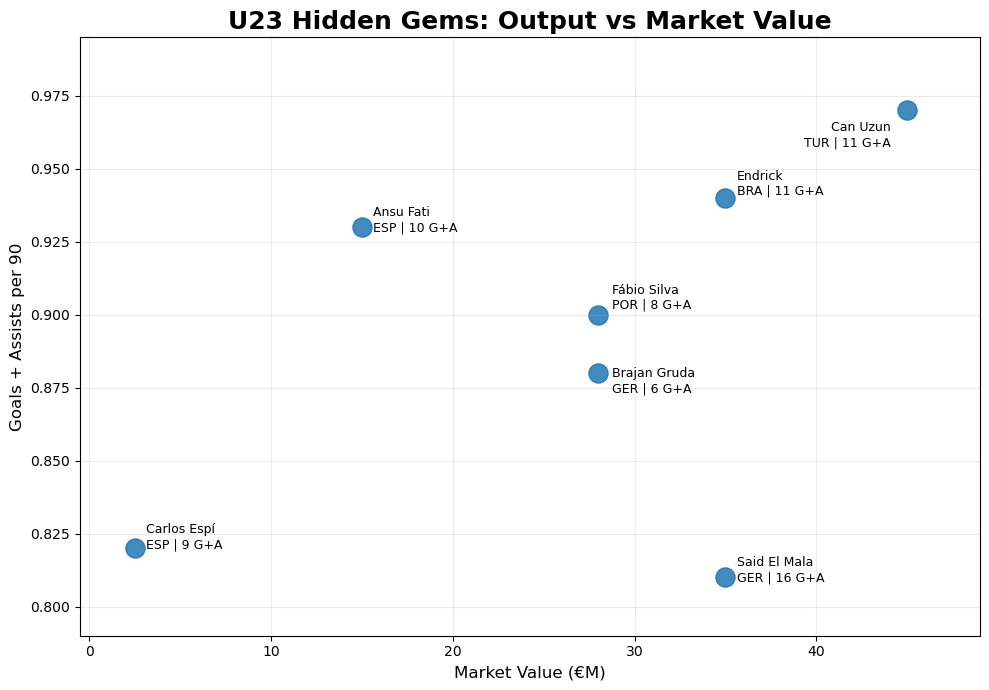

In [134]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = high_g_a_per_90_minutes.copy()

plot_df["G+A per 90 Min"] = pd.to_numeric(plot_df["G+A per 90 Min"], errors="coerce")
plot_df["Market Value (€)"] = pd.to_numeric(plot_df["Market Value (€)"], errors="coerce")
plot_df["Goals + Assists"] = pd.to_numeric(plot_df["Goals + Assists"], errors="coerce")

plot_df["market_value_m"] = plot_df["Market Value (€)"] / 1_000_000
plot_df = plot_df.dropna(subset=["G+A per 90 Min", "market_value_m"])

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    plot_df["market_value_m"],
    plot_df["G+A per 90 Min"],
    s=190,
    alpha=0.85
)

# Custom label offsets: (x_offset, y_offset, horizontal_alignment)
label_offsets = {
    "Can Uzun": (-12, -18, "right"),
    "Endrick": (8, 10, "left"),
    "Ansu Fati": (8, 5, "left"),
    "Fábio Silva": (10, 12, "left"),
    "Brajan Gruda": (10, -6, "left"),
    "Carlos Espí": (8, 8, "left"),
    "Said El Mala": (8, 5, "left"),
}

for _, row in plot_df.iterrows():
    name = row["player"]

    x_offset, y_offset, ha = label_offsets.get(name, (10, 8, "left"))

    label = f"{name}\n{row['nation']} | {int(row['Goals + Assists'])} G+A"

    ax.annotate(
        label,
        (row["market_value_m"], row["G+A per 90 Min"]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=9,
        ha=ha,
        va="center"
    )

ax.set_title("U23 Hidden Gems: Output vs Market Value", fontsize=18, weight="bold")
ax.set_xlabel("Market Value (€M)", fontsize=12)
ax.set_ylabel("Goals + Assists per 90", fontsize=12)

# Add a little extra padding so labels don't hit the edge
ax.set_xlim(plot_df["market_value_m"].min() - 3, plot_df["market_value_m"].max() + 4)
ax.set_ylim(plot_df["G+A per 90 Min"].min() - 0.02, plot_df["G+A per 90 Min"].max() + 0.025)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()